# User Cluster Journey Analysis
Track and visualize how all Instagram users switch between clusters over time (2023-01 to 2026-03).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Prepare Data

In [2]:
# Load both CSV files only if the bootstrap cell has not already done it
if 'df_monthly' not in globals() or 'df_windowlevel' not in globals():
    data_dir = r"d:\Polythecninco di Milano\AFB_Lab\Mickey\RFM_IG_rolling_quadrimesters"
    df_monthly = pd.read_csv(data_dir + r"\Ig_RCEDTG_k4_monthly_cluster_matrix.csv")
    df_windowlevel = pd.read_csv(data_dir + r"\Ig_RCEDTG_windowlevel_kmeans_k4_monthly_cluster_matrix.csv")

print(f"Monthly data shape: {df_monthly.shape}")
print(f"Window-level data shape: {df_windowlevel.shape}")
print("\nColumns in monthly data:")
print(df_monthly.columns.tolist())
print("\nFirst few rows of monthly data:")
print(df_monthly.head(2))
print("\nData types:")
print(df_monthly.dtypes)

Monthly data shape: (18752, 42)
Window-level data shape: (18752, 42)

Columns in monthly data:
['user_key', 'user_id', 'username', '2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']

First few rows of monthly data:
           user_key       user_id   username         2023-01         2023-02  \
0  1452263009584630  1.452263e+15       00bc  Not yet active  Not yet active   
1  1529027545186143  1.529028e+15  074serena  Not yet active  Not yet active   

          2023-03         2023-04         2023-05         2023-06  \
0  Not yet active  Not yet active  Not yet active  Not yet active   
1  Not yet active  Not yet a

## 2. All Users

In [3]:
# Use all monthly users instead of a sample
sampled_users = df_monthly[['user_key', 'user_id', 'username']].drop_duplicates().merge(
    df_monthly, on=['user_key', 'user_id', 'username'], how='left'
)

if 'month_columns' not in globals():
    month_columns = [col for col in df_monthly.columns if col not in ['user_key', 'user_id', 'username']]

print(f"Loaded {len(sampled_users)} users")
print("\nAll users:")
print(sampled_users[['user_key', 'user_id', 'username']].to_string(index=False))
print(f"\nNumber of time periods: {len(month_columns)}")
print(f"Date range: {month_columns[0]} to {month_columns[-1]}")

Loaded 18752 users

All users:
                    user_key      user_id                       username
            1452263009584630 1.452263e+15                           00bc
            1529027545186143 1.529028e+15                      074serena
            4117121325206183 4.117121e+15                      077.matte
             912267428379016 9.122674e+14                          09deh
            1412339077303492 1.412339e+15                     0_val_le_0
            2505361169921583 2.505361e+15                          0bis0
            2165276267340493 2.165276e+15                     0mel_anje0
            2280568539137717 2.280569e+15                   123_stellaaa
            1956445981616162 1.956446e+15                      12trip.it
            1412864567519239 1.412865e+15                   141goingdark
             957927240511276 9.579272e+14                    16roserosse
             949439044279046 9.494390e+14                       17101981
            14607508

## 3. Transform Data to Long Format for Journey Tracking

In [4]:
# Transform data from wide to long format (always recompute to avoid stale state)
sampled_data_long = sampled_users.melt(
    id_vars=['user_key', 'user_id', 'username'],
    value_vars=month_columns,
    var_name='month',
    value_name='cluster'
)
sampled_data_long['month'] = pd.to_datetime(sampled_data_long['month'], errors='coerce')
sampled_data_long = sampled_data_long.sort_values(['user_id', 'month']).reset_index(drop=True)
sampled_data_long['prev_cluster'] = sampled_data_long.groupby('user_id')['cluster'].shift(1)
sampled_data_long['transition'] = np.where(
    sampled_data_long['prev_cluster'].isna(),
    np.nan,
    sampled_data_long['prev_cluster'].astype(str) + ' -> ' + sampled_data_long['cluster'].astype(str)
)

# Explicit change flag used by transition-focused charts
sampled_data_long['is_change'] = sampled_data_long['cluster'] != sampled_data_long['prev_cluster']
sampled_data_long.loc[sampled_data_long['prev_cluster'].isna(), 'is_change'] = False

print(f'Long format data shape: {sampled_data_long.shape}')
print('\nFirst 10 rows:')
print(sampled_data_long.head(10))
print('\nCluster distribution:')
print(sampled_data_long['cluster'].value_counts())
print('\nSample transitions:')
print(sampled_data_long[['username', 'month', 'prev_cluster', 'cluster', 'transition', 'is_change']].head(15))

Long format data shape: (731328, 8)

First 10 rows:
          user_key       user_id    username      month         cluster  \
0  623742630834353  6.237426e+14  valecori91 2023-01-01  Not yet active   
1  623742630834353  6.237426e+14  valecori91 2023-02-01  Not yet active   
2  623742630834353  6.237426e+14  valecori91 2023-03-01  Not yet active   
3  623742630834353  6.237426e+14  valecori91 2023-04-01  Not yet active   
4  623742630834353  6.237426e+14  valecori91 2023-05-01              C3   
5  623742630834353  6.237426e+14  valecori91 2023-06-01              C3   
6  623742630834353  6.237426e+14  valecori91 2023-07-01              C3   
7  623742630834353  6.237426e+14  valecori91 2023-08-01              C3   
8  623742630834353  6.237426e+14  valecori91 2023-09-01        Inactive   
9  623742630834353  6.237426e+14  valecori91 2023-10-01        Inactive   

     prev_cluster                        transition  is_change  
0             NaN                               NaN      

## 4. Full-Cohort Visualizations (Scalable)

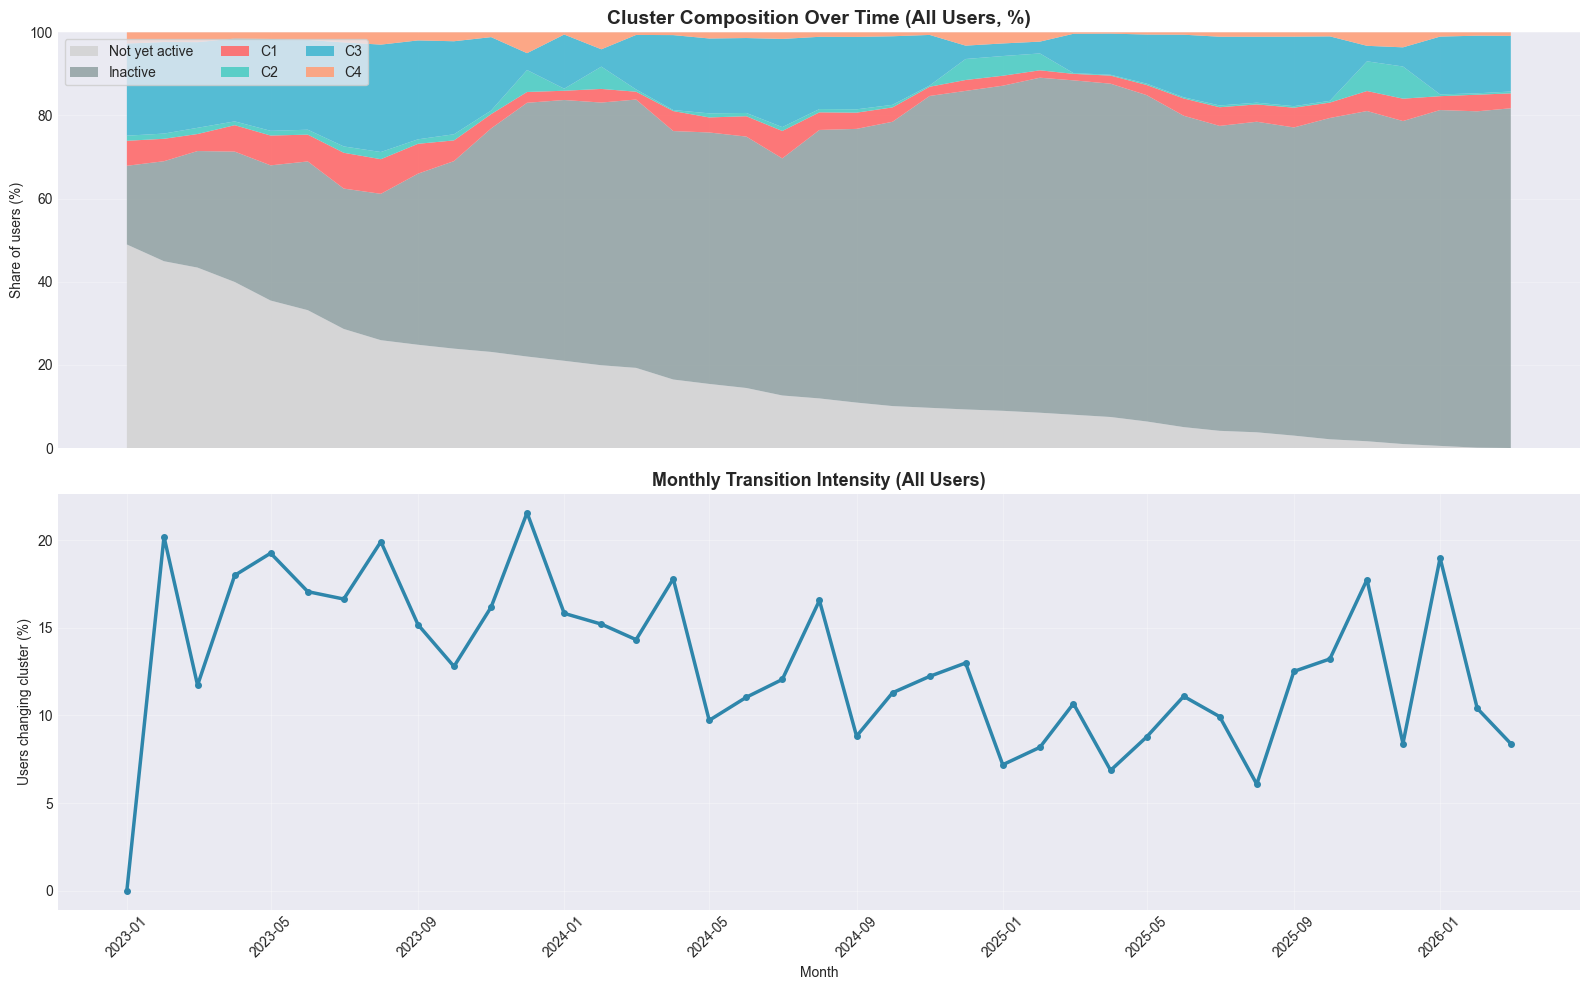

Scalable full-cohort visualizations created!


In [5]:
# Full-cohort visualizations that scale beyond a small user sample
cluster_colors = {
    'C1': '#FF6B6B',
    'C2': '#4ECDC4',
    'C3': '#45B7D1',
    'C4': '#FFA07A',
    'Inactive': '#95A5A6',
    'Not yet active': '#D3D3D3'
}

cluster_order = ['Not yet active', 'Inactive', 'C1', 'C2', 'C3', 'C4']
clusters_present = [c for c in cluster_order if c in sampled_data_long['cluster'].unique()]
if not clusters_present:
    clusters_present = sorted(sampled_data_long['cluster'].dropna().unique().tolist())

cluster_to_numeric = {c: i for i, c in enumerate(clusters_present)}
cluster_numeric_reverse = {i: c for c, i in cluster_to_numeric.items()}

# 1) Monthly composition as percentage (100% stacked area)
monthly_counts = sampled_data_long.groupby(['month', 'cluster']).size().unstack(fill_value=0)
monthly_counts = monthly_counts.reindex(columns=clusters_present, fill_value=0)
monthly_share = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100

# 2) Monthly transition intensity (% users that changed cluster since previous month)
transition_intensity = (
    sampled_data_long.dropna(subset=['prev_cluster'])
    .assign(is_change=lambda d: d['cluster'] != d['prev_cluster'])
    .groupby('month')['is_change']
    .mean()
    .mul(100)
    .reindex(monthly_share.index)
    .fillna(0)
 )

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

axes[0].stackplot(
    monthly_share.index,
    [monthly_share[c].values for c in monthly_share.columns],
    labels=monthly_share.columns,
    colors=[cluster_colors.get(c, '#999999') for c in monthly_share.columns],
    alpha=0.9
)
axes[0].set_title('Cluster Composition Over Time (All Users, %)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Share of users (%)')
axes[0].set_ylim(0, 100)
axes[0].legend(loc='upper left', ncol=3, frameon=True)
axes[0].grid(True, alpha=0.25)

axes[1].plot(
    transition_intensity.index,
    transition_intensity.values,
    color='#2E86AB',
    linewidth=2.5,
    marker='o',
    markersize=4
)
axes[1].set_title('Monthly Transition Intensity (All Users)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Users changing cluster (%)')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('cohort_composition_and_transition_intensity.svg', format='svg', bbox_inches='tight')
plt.savefig('cohort_composition_and_transition_intensity.png', dpi=300, bbox_inches='tight')
plt.show()

print('Scalable full-cohort visualizations created!')

## 5. Summary Statistics and Transition Analysis

In [6]:
# Calculate time spent in each cluster per user
time_in_cluster = sampled_data_long.groupby(['user_id', 'username', 'cluster']).size().reset_index(name='months')
print("Time spent in each cluster (per user):")
print(time_in_cluster.sort_values('months', ascending=False).head(20))

# Calculate cluster transition matrix
transition_counts = sampled_data_long.dropna(subset=['transition']).groupby('transition').size().reset_index(name='count')
transition_counts = transition_counts.sort_values('count', ascending=False)
print("\n\nMost common transitions:")
print(transition_counts.head(15))

# Calculate percentage of users in each cluster state
cluster_distribution = sampled_data_long['cluster'].value_counts()
cluster_pct = (cluster_distribution / len(sampled_data_long) * 100).round(2)
print("\n\nOverall cluster distribution:")
for cluster, pct in cluster_pct.items():
    print(f"{cluster}: {pct}%")

# Analyze transitions into and out of each cluster
def analyze_cluster_flows(data, cluster_name):
    """Analyze inflow and outflow for a specific cluster"""
    inflow = data[data['cluster'] == cluster_name]['transition'].value_counts()
    print(f"\n{cluster_name} - Inflow transitions (top 5):")
    print(inflow.head())

for cluster in ['C1', 'C2', 'C3', 'C4', 'Inactive']:
    if cluster in sampled_data_long['cluster'].values:
        analyze_cluster_flows(sampled_data_long, cluster)

Time spent in each cluster (per user):
            user_id              username   cluster  months
63873  3.524999e+16              cladev23  Inactive      39
59434  4.170994e+15              matimac_  Inactive      39
17925  1.191066e+15          camilla_rima  Inactive      39
17884  1.188271e+15         langolodidani  Inactive      39
47234  1.952926e+15          saraaronadio  Inactive      39
35596  1.522716e+15           marika.n_88  Inactive      39
1263   7.807748e+14          bartowski___  Inactive      39
62763  2.636825e+16     rossellasagliocco  Inactive      39
35883  1.542016e+15             valebunny  Inactive      39
35999  1.548496e+15       chiara_campaini        C1      39
15970  9.741444e+14    ilaria_reviewsrose  Inactive      39
3384   8.234754e+14     mariangelalai1988  Inactive      39
48653  2.000961e+15         bellaviaholly  Inactive      39
3388   8.236292e+14              meryuus_  Inactive      39
19985  1.243668e+15            ilaria1707  Inactive      39
3

In [7]:
# Identify and analyze interesting user journeys
print("=" * 80)
print("INTERESTING USER JOURNEYS ANALYSIS")
print("=" * 80)

# 1. Most volatile users (most transitions)
if 'summary_df' not in globals():
    if 'sampled_data_long' not in globals():
        raise NameError("sampled_data_long is not defined. Run the preprocessing cells first.")

    _tmp = sampled_data_long.sort_values(['user_id', 'month']).copy()
    summary_df = (
        _tmp.groupby('user_id')
        .apply(lambda g: pd.Series({
            'username': g['username'].iloc[0],
            'unique_clusters': g['cluster'].nunique(),
            'first_cluster': g['cluster'].iloc[0],
            'last_cluster': g['cluster'].iloc[-1],
            'num_transitions': g['transition'].notna().sum(),
            'most_common_cluster': g['cluster'].mode().iloc[0],
            'active_months': (~g['cluster'].isin(['Inactive', 'Not yet active'])).sum(),
            'total_months': len(g)
        }))
        .reset_index()
    )

most_volatile = summary_df.nlargest(5, 'num_transitions')
print("\n1. MOST VOLATILE USERS (Most cluster transitions):")
print(most_volatile[['username', 'num_transitions', 'unique_clusters', 'first_cluster', 'last_cluster']].to_string())

# 2. Most stable users (least transitions)
most_stable = summary_df.nsmallest(5, 'num_transitions')
print("\n2. MOST STABLE USERS (Fewest transitions):")
print(most_stable[['username', 'num_transitions', 'most_common_cluster', 'active_months']].to_string())

# 3. Users who became inactive
became_inactive_users = summary_df[summary_df['last_cluster'] == 'Inactive'].nlargest(5, 'active_months')
print("\n3. USERS WHO BECAME INACTIVE (Most active before going inactive):")
print(became_inactive_users[['username', 'active_months', 'first_cluster', 'most_common_cluster']].to_string())

# 4. Users who are still active
still_active_users = summary_df[summary_df['last_cluster'].isin(['C1', 'C2', 'C3', 'C4'])]
print(f"\n4. USERS STILL ACTIVE: {len(still_active_users)} users")
print("Latest cluster distribution among active users:")
print(still_active_users['last_cluster'].value_counts())

# 5. Show one detailed example
print("\n" + "=" * 80)
print("DETAILED EXAMPLE: User with most transitions")
example_user_id = summary_df.nlargest(1, 'num_transitions')['user_id'].iloc[0]
example_user_data = sampled_data_long[sampled_data_long['user_id'] == example_user_id]
print(f"\nUser: {example_user_data['username'].iloc[0]}")
print(f"Period: {example_user_data['month'].min().strftime('%Y-%m')} to {example_user_data['month'].max().strftime('%Y-%m')}")
print(f"\nCluster history:")
print(example_user_data[['month', 'cluster', 'transition']].to_string())

INTERESTING USER JOURNEYS ANALYSIS

1. MOST VOLATILE USERS (Most cluster transitions):
           username  num_transitions  unique_clusters   first_cluster last_cluster
0        valecori91               38                4  Not yet active     Inactive
1           giu_pac               38                5  Not yet active     Inactive
2  alicescalambrino               38                3  Not yet active     Inactive
3        a_talassia               38                4  Not yet active     Inactive
4      lapennadicla               38                5  Not yet active           C3

2. MOST STABLE USERS (Fewest transitions):
           username  num_transitions most_common_cluster  active_months
0        valecori91               38            Inactive              8
1           giu_pac               38            Inactive              5
2  alicescalambrino               38            Inactive             12
3        a_talassia               38            Inactive              8
4      lape

## 6. Interactive Dashboard with Transition Heatmaps

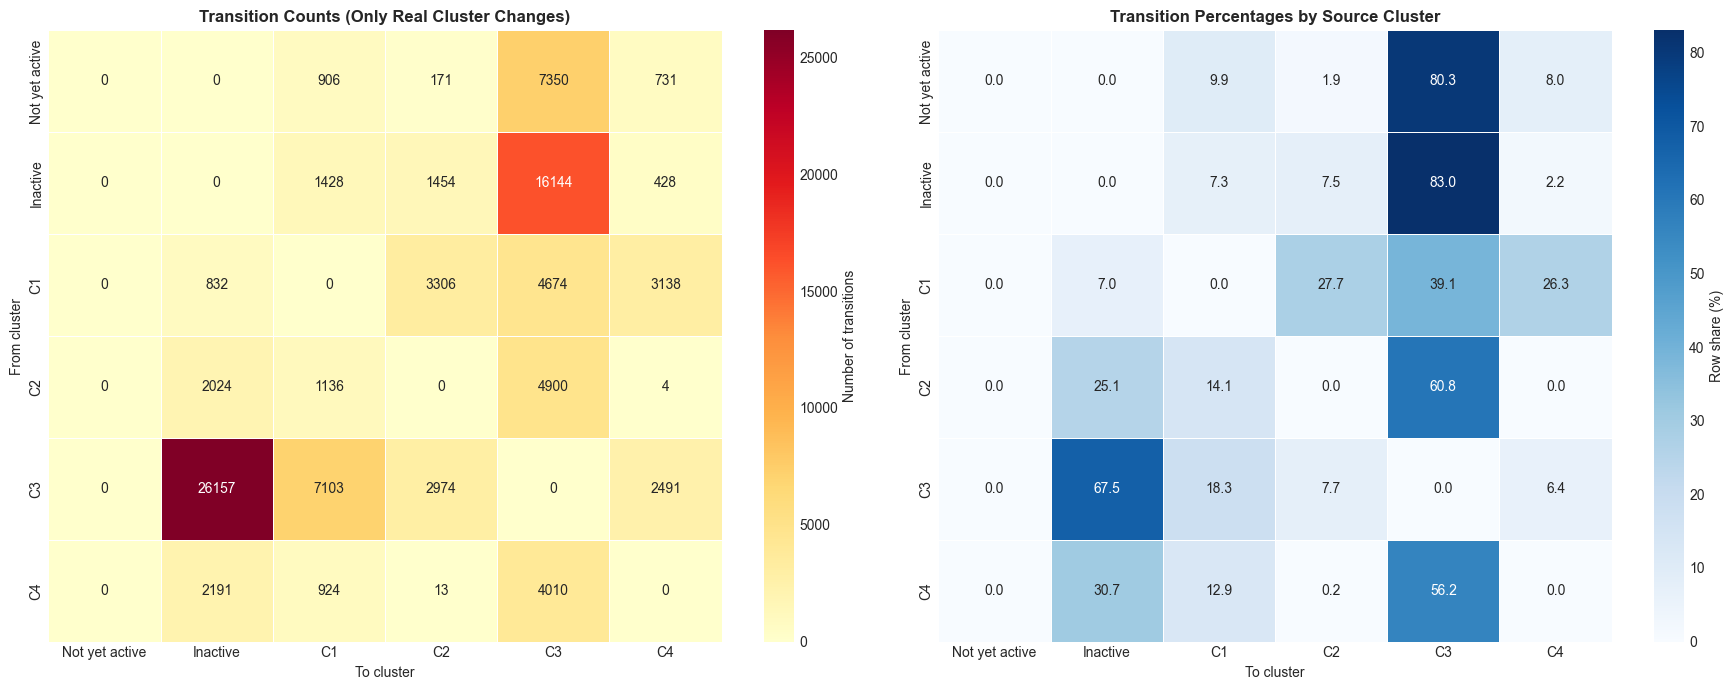

Transition matrices created for full cohort!


In [8]:
# Transition matrix for full cohort: counts + row-normalized percentages
sampled_data_long_valid = sampled_data_long.dropna(subset=['prev_cluster', 'cluster']).copy()
sampled_data_long_valid['is_change'] = sampled_data_long_valid['cluster'] != sampled_data_long_valid['prev_cluster']
sampled_data_long_valid = sampled_data_long_valid[sampled_data_long_valid['is_change']].copy()

transition_matrix = pd.crosstab(
    sampled_data_long_valid['prev_cluster'],
    sampled_data_long_valid['cluster']
).reindex(index=clusters_present, columns=clusters_present, fill_value=0)

row_totals = transition_matrix.sum(axis=1).replace(0, np.nan)
transition_matrix_pct = transition_matrix.div(row_totals, axis=0) * 100
transition_matrix_pct = transition_matrix_pct.fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    transition_matrix,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Number of transitions'},
    ax=axes[0],
    linewidths=0.5
)
axes[0].set_title('Transition Counts (Only Real Cluster Changes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('To cluster')
axes[0].set_ylabel('From cluster')

sns.heatmap(
    transition_matrix_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Row share (%)'},
    ax=axes[1],
    linewidths=0.5
)
axes[1].set_title('Transition Percentages by Source Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('To cluster')
axes[1].set_ylabel('From cluster')

plt.tight_layout()
plt.savefig('transition_matrix_counts_and_percentages.svg', format='svg', bbox_inches='tight')
plt.savefig('transition_matrix_counts_and_percentages.png', dpi=300, bbox_inches='tight')
plt.show()

print('Transition matrices created for full cohort!')

In [9]:
# Sankey diagram using top transition flows for readability on full cohort
sankey_data = (
    sampled_data_long_valid
    .groupby(['prev_cluster', 'cluster'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
 )

top_links = sankey_data.head(20).copy()
coverage_pct = top_links['count'].sum() / sankey_data['count'].sum() * 100 if len(sankey_data) else 0

all_clusters = sorted(set(top_links['prev_cluster'].unique()) | set(top_links['cluster'].unique()))
cluster_to_idx = {c: i for i, c in enumerate(all_clusters)}

source = [cluster_to_idx[c] for c in top_links['prev_cluster']]
target = [cluster_to_idx[c] for c in top_links['cluster']]
value = top_links['count'].tolist()

node_colors = [cluster_colors.get(c, '#999999') for c in all_clusters]
link_colors = [cluster_colors.get(c, '#BBBBBB') for c in top_links['prev_cluster']]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=18,
        thickness=22,
        line=dict(color='black', width=0.5),
        label=all_clusters,
        color=node_colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors
    )
)])

fig.update_layout(
    title=f'Top 20 Transition Flows (All Users) - Covers {coverage_pct:.1f}% of all changes',
    font=dict(size=12),
    height=650,
    width=1100
)
fig.show()

print('Sankey diagram created (top flows for readability)!')

Sankey diagram created (top flows for readability)!


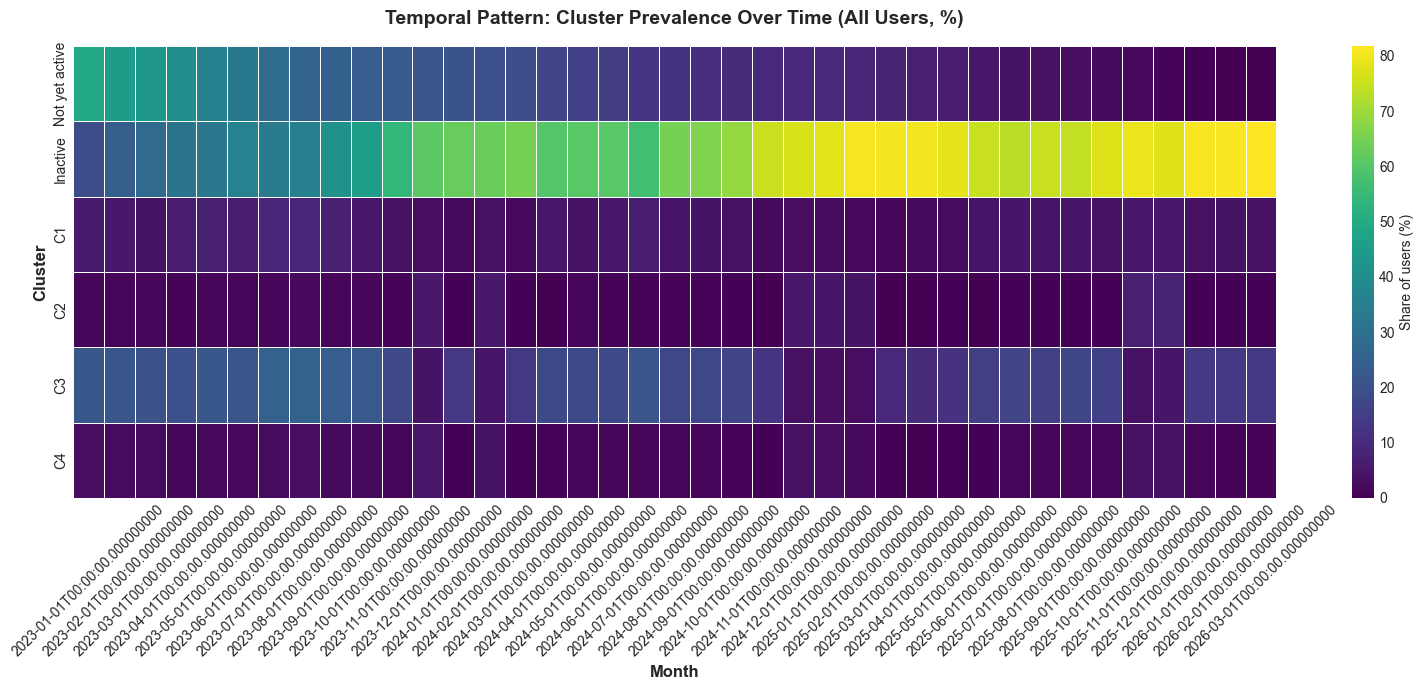

Temporal percentage heatmap created!


In [10]:
# Temporal heatmap on percentages for full-cohort comparability
temporal_share = sampled_data_long.groupby(['month', 'cluster']).size().unstack(fill_value=0)
temporal_share = temporal_share.reindex(columns=clusters_present, fill_value=0)
temporal_share = temporal_share.div(temporal_share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    temporal_share.T,
    cmap='viridis',
    cbar_kws={'label': 'Share of users (%)'},
    ax=ax,
    linewidths=0.5
)
ax.set_title('Temporal Pattern: Cluster Prevalence Over Time (All Users, %)', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('temporal_cluster_share_heatmap.svg', format='svg', bbox_inches='tight')
plt.savefig('temporal_cluster_share_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('Temporal percentage heatmap created!')

In [11]:
# Interactive full-cohort view: stacked area of monthly cluster shares
interactive_share = temporal_share.reset_index().melt(
    id_vars='month',
    var_name='cluster',
    value_name='pct_users'
)

fig = px.area(
    interactive_share,
    x='month',
    y='pct_users',
    color='cluster',
    category_orders={'cluster': clusters_present},
    color_discrete_map=cluster_colors,
    labels={'month': 'Month', 'pct_users': 'Share of users (%)', 'cluster': 'Cluster'},
    title='Interactive Cluster Share Over Time (All Users)'
)

fig.update_layout(
    height=650,
    yaxis=dict(title='Share of users (%)', range=[0, 100]),
    xaxis_title='Month',
    hovermode='x unified',
    legend_title='Cluster'
 )
fig.update_xaxes(rangeslider_visible=True, tickangle=-45)
fig.show()

## 7. Export Summary Report

## 8. Users Who Never Entered Inactive

Users with no Inactive months: 597 out of 18712 total users
Percentage: 3.2%

Distribution by last cluster:
last_cluster
Not yet active      0
Inactive            0
C1                206
C2                  7
C3                256
C4                128

Distribution by most common cluster:
most_common_cluster
Not yet active    561
Inactive            0
C1                 35
C2                  0
C3                  1
C4                  0


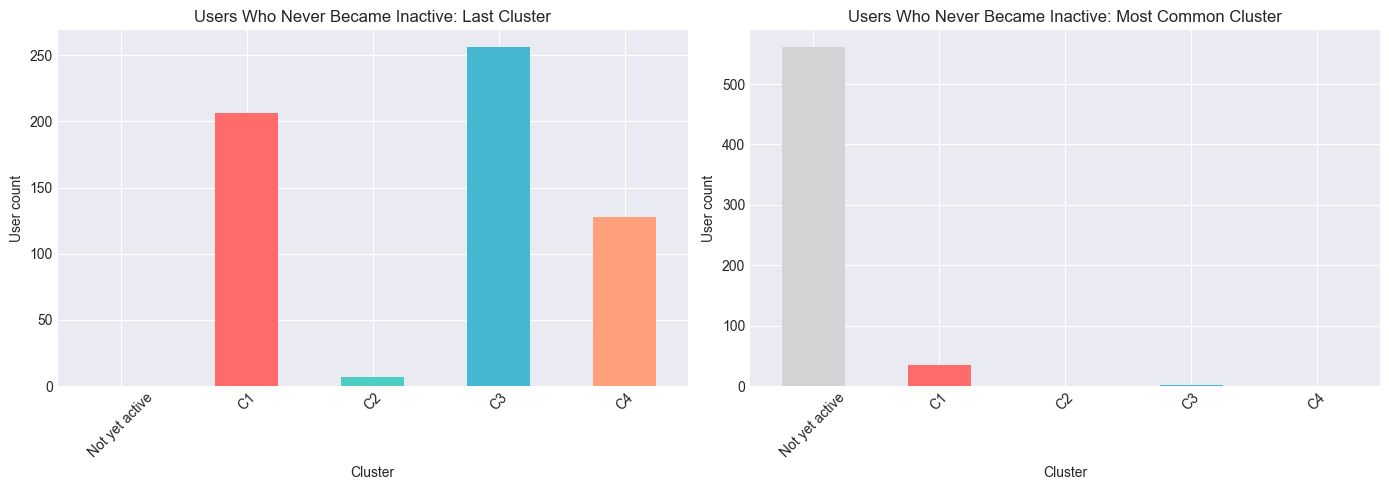


Top 10 users in the no-Inactive cohort:
     user_id           username  first_cluster last_cluster most_common_cluster  total_months
6.829505e+14        disagiada96 Not yet active           C4      Not yet active            39
6.892079e+14 anacletopelliccia_ Not yet active           C3      Not yet active            39
7.045296e+14        darkxsystem Not yet active           C3      Not yet active            39
7.205572e+14 nonsologiornalista Not yet active           C1      Not yet active            39
7.338071e+14        sarametalli Not yet active           C3      Not yet active            39
7.361879e+14          _just_tea Not yet active           C4      Not yet active            39
7.483540e+14     stemetamorfosi Not yet active           C3      Not yet active            39
7.666757e+14          bagiale07 Not yet active           C4      Not yet active            39
7.718172e+14    davide.t.vecchi Not yet active           C4      Not yet active            39
7.760339e+14       

In [12]:
# Users whose tenure never includes Inactive
never_inactive_mask = sampled_data_long.groupby('user_id')['cluster'].apply(lambda s: (s != 'Inactive').all())
never_inactive_users = sampled_data_long[sampled_data_long['user_id'].isin(never_inactive_mask[never_inactive_mask].index)].copy()
never_inactive_summary = never_inactive_users.groupby('user_id').agg(
    username=('username', 'first'),
    first_cluster=('cluster', 'first'),
    last_cluster=('cluster', 'last'),
    most_common_cluster=('cluster', lambda s: s.mode().iloc[0]),
    total_months=('cluster', 'size')
).reset_index()

print(f"Users with no Inactive months: {len(never_inactive_summary)} out of {sampled_users['user_id'].nunique()} total users")
print(f"Percentage: {len(never_inactive_summary) / sampled_users['user_id'].nunique() * 100:.1f}%")
print("\nDistribution by last cluster:")
last_cluster_dist = never_inactive_summary['last_cluster'].value_counts().reindex(cluster_order, fill_value=0)
print(last_cluster_dist.to_string())

print("\nDistribution by most common cluster:")
most_common_dist = never_inactive_summary['most_common_cluster'].value_counts().reindex(cluster_order, fill_value=0)
print(most_common_dist.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

last_cluster_dist = last_cluster_dist[last_cluster_dist.index.isin(['C1', 'C2', 'C3', 'C4', 'Not yet active'])]
last_cluster_dist.plot(kind='bar', ax=axes[0], color=[cluster_colors.get(idx, '#999999') for idx in last_cluster_dist.index])
axes[0].set_title('Users Who Never Became Inactive: Last Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('User count')
axes[0].tick_params(axis='x', rotation=45)

most_common_dist = most_common_dist[most_common_dist.index.isin(['C1', 'C2', 'C3', 'C4', 'Not yet active'])]
most_common_dist.plot(kind='bar', ax=axes[1], color=[cluster_colors.get(idx, '#999999') for idx in most_common_dist.index])
axes[1].set_title('Users Who Never Became Inactive: Most Common Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('User count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('never_inactive_cluster_distribution.svg', format='svg', bbox_inches='tight')
plt.savefig('never_inactive_cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 users in the no-Inactive cohort:")
print(never_inactive_summary.head(10).to_string(index=False))

In [13]:
# Export summary statistics to CSV
summary_report = []

for user_id in sampled_data_long['user_id'].unique():
    user_data = sampled_data_long[sampled_data_long['user_id'] == user_id]
    username = user_data['username'].iloc[0]

    # Count unique clusters
    unique_clusters = user_data['cluster'].nunique()

    # Find first and last cluster state
    first_cluster = user_data.iloc[0]['cluster']
    last_cluster = user_data.iloc[-1]['cluster']

    # Count actual cluster changes
    num_transitions = user_data['is_change'].sum()

    # Most common cluster
    most_common_cluster = user_data['cluster'].value_counts().index[0]

    # Count of active periods (non-Inactive, non-"Not yet active")
    active_periods = len(user_data[~user_data['cluster'].isin(['Inactive', 'Not yet active'])])

    summary_report.append({
        'user_id': user_id,
        'username': username,
        'unique_clusters': unique_clusters,
        'first_cluster': first_cluster,
        'last_cluster': last_cluster,
        'num_transitions': num_transitions,
        'most_common_cluster': most_common_cluster,
        'active_months': active_periods,
        'total_months': len(user_data)
    })

summary_df = pd.DataFrame(summary_report)

# Save to CSV
summary_df.to_csv('user_cluster_journey_summary.csv', index=False)

print("\nSummary Report (first 10 users):")
print(summary_df.head(10))

print("\n\nSummary Statistics:")
print(f"Total sampled users: {len(summary_df)}")
print(f"Average unique clusters per user: {summary_df['unique_clusters'].mean():.2f}")
print(f"Average transitions per user: {summary_df['num_transitions'].mean():.2f}")
print(f"Average active months per user: {summary_df['active_months'].mean():.2f}")

# Calculate users who became inactive
became_inactive = (summary_df['last_cluster'] == 'Inactive').sum()
print(f"\nUsers who ended in Inactive state: {became_inactive} ({became_inactive/len(summary_df)*100:.1f}%)")

# Calculate users still active
still_active = (summary_df['last_cluster'].isin(['C1', 'C2', 'C3', 'C4'])).sum()
print(f"Users still active (in cluster): {still_active} ({still_active/len(summary_df)*100:.1f}%)")

print("\nSummary report saved to 'user_cluster_journey_summary.csv'")

IndexError: single positional indexer is out-of-bounds